For more information visit:

*    [Psychometric properties of the 21-item Depression, Anxiety, and Stress Scale ](https://www.nature.com/articles/s41599-022-01229-x)

*  [Development and Validation of the Depression Anxiety Stress Scale](https://pmc.ncbi.nlm.nih.gov/articles/PMC8507889/)

*  [Assessment and Psychometric Properties of the 21-Item](https://pmc.ncbi.nlm.nih.gov/articles/PMC10670895/)



In [1]:
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
pip install itables
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.4 MB/s eta 0:00:00


In [2]:
github_csv_url = 'https://raw.githubusercontent.com/MrSayantanRay/Psychometric-Predictor/master/adult%20mental%20health%20in%20indian%20metro%20cities%202001-2021(cleaned).csv'
mh = pd.read_csv(github_csv_url)
mh

Loading ITables v2.8.1 from the internet... (need help?)


In [ ]:
mh.drop(columns=['name', 'religion', 'caste', 'owned/rented', 'mpce T1', 'mpce T2'], inplace=True)
mh.head()

Loading ITables v2.8.1 from the internet... (need help?)


In [ ]:
mh

Loading ITables v2.8.1 from the internet... (need help?)


In [ ]:
print(mh.columns.tolist())

['slno', 'city', 'age', 'sex', 'study_level', 'occupation', 'empl_st_before_lckdwn', 'pymnt_st_main_erng_memb', 'family_mems', 'agd_memb_above60', 'mrd_and_spouse_living_together_or_not', 'residential_pattern', 'change_of_occ', 'change_of_occ_mainmember', 'married_unmarried', 'residence_change', 'family_economicaly_affected T1', 'family_economicaly_affected T2', 'monthly_expenditure T1', 'monthly_expenditure T2', 'education_of_children T1', 'education_of_children T2', 'leisure_time T1', 'leisure_time T2', 'covid_case T1', 'covid_case T2', 'fam_mem_suff_hyp-tens/bp/dbts/canc T1', 'fam_mem_suff_hyp-tens/bp/dbts/canc T2', 'finding_hard_to_wind_down_T1', 'finding_hard_to_wind_down_T2', 'dry_mouth T1', 'dry_mouth T2', 'not_experiencing_+ve_felling T1', 'not_experiencing_+ve_felling T2', 'breathing_difficulty T1', 'breathing_difficulty T2', 'difficulty_in_initiative_to_do_things T1', 'difficulty_in_initiative_to_do_things T2', 'overreaction_in_situations T1', 'overreaction_in_situations T2',

In [ ]:
mh.rename(columns={'finding_hard_to_wind_down_T1': 'finding_hard_to_wind_down T1', 'finding_hard_to_wind_down_T2': 'finding_hard_to_wind_down T2'}, inplace=True)


##Separating the Longitudinal Data

In [ ]:
mh_clean = mh.drop(columns=['relative_dep','relative_anx','relative_stress'])

# Shared/static columns (keep in both)
common_cols = [
    c for c in mh_clean.columns
    if (' T1' not in c and ' T2' not in c)
]

t1_cols = [c for c in mh_clean.columns if c.endswith(' T1')]
t2_cols = [c for c in mh_clean.columns if c.endswith(' T2')]

# Build T1
mh_T1 = mh_clean[
    common_cols + t1_cols
].copy()

# Build T2
mh_T2 = mh_clean[
    common_cols + t2_cols
].copy()

# Remove suffixes
mh_T1.columns = [
    c.replace(' T1', '')
    for c in mh_T1.columns
]

mh_T2.columns = [
    c.replace(' T2', '')
    for c in mh_T2.columns
]

mh_T1.to_csv("mh_T1.csv", index=False)
mh_T2.to_csv("mh_T2.csv", index=False)

print(mh_T1.shape)
print(mh_T2.shape)

(978, 51)
(978, 49)


In [ ]:
mh_T1['family_economicaly_affected'].unique()

array(['Reduced income due to poor business', 'Pay cut',
       'No / No Applicable', 'Irregular pay', 'Lost job', 'Any other way'],
      dtype=object)

In [ ]:
mh_T1['education_of_children'].fillna('Unknown', inplace=True)

/tmp/ipykernel_7642/2993924568.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mh_T1['education_of_children'].fillna('Unknown', inplace=True)


In [ ]:
mh_T1['education_of_children'].unique()

array(['Somewhat affected', 'Unknown', 'Severely affected',
       'Not affected'], dtype=object)

In [ ]:
mh_T1.head(2)

Loading ITables v2.8.1 from the internet... (need help?)


##ML modeling starts

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder, StandardScaler)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
# Defining the ordinal categories for survey questions
ordinal_cols = ['finding_hard_to_wind_down', 'dry_mouth', 'not_experiencing_+ve_felling',
                'breathing_difficulty', 'difficulty_in_initiative_to_do_things',
                'overreaction_in_situations', 'experienced_trembling',
               'felt_used_lotsof_nrvs_engy', 'panic_in_situations&make_fool_of_own',
                'felt_had_nothing_to_look_forward', 'getting_agitated', 'difficulty_in_relax',
                'felt_downhearted_and_blue', 'intolerant_of_anything_gotin_my_way',
                'felt_like_panicking', 'unable_to_become_enthusiastic',
                'felt_unworthy_as_a_person', 'felt_being_touchy',
                'abnormal_heart_rate', 'felt_scared_without_reason', 'felt_life_is_meaningless']

In [ ]:
features = ordinal_cols + ['family_economicaly_affected', 'education_of_children', 'covid_case']
X = mh_T1[features]
y = mh_T1['depression_level']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#Stratify preserves class proportions

print(len(X_train))
print(len(X_test))

782
196


In [ ]:
transformer = ColumnTransformer(transformers=[
    ('tnf1', OrdinalEncoder(categories=[['Did not apply to me at all',
                                         'Applied to me to some degree of some of the time',
                                         'Applied to me to a considerable time or good part of time',
                                         'Applied to me very much or most of the time']] * len(ordinal_cols)), ordinal_cols),
    ('tnf2', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), ['family_economicaly_affected', 'education_of_children', 'covid_case'])
], remainder='passthrough')

In [ ]:
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

In [ ]:
print(X_train_transformed.shape)
X_test_transformed.shape

(782, 31)


(196, 31)

In [ ]:
# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_transformed)
X_test_scaled = scaler.transform(X_test_transformed)

# Train lg with scaled data
lg = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    random_state=42
)

lg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)

In [ ]:
print(lg.n_iter_)

[78]


In [ ]:
# Use the scaled test data for prediction
y_pred = lg.predict(X_test_scaled)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nWeighted F1:")
print(f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

#Support = Row sum of Confusion Matrrix = Number of actual observations

Accuracy:
0.9081632653061225

Weighted F1:
0.9115488954567027

Classification Report:
                  precision    recall  f1-score   support

Extremely severe       0.92      0.92      0.92        24
            Mild       0.62      0.79      0.70        19
        Moderate       0.88      0.94      0.91        32
          Normal       0.99      0.93      0.96        99
          Severe       0.90      0.86      0.88        22

        accuracy                           0.91       196
       macro avg       0.86      0.89      0.87       196
    weighted avg       0.92      0.91      0.91       196


Confusion Matrix:
[[22  0  0  0  2]
 [ 0 15  3  1  0]
 [ 0  2 30  0  0]
 [ 0  7  0 92  0]
 [ 2  0  1  0 19]]


In [ ]:
y_test.value_counts()

Loading ITables v2.8.1 from the internet... (need help?)


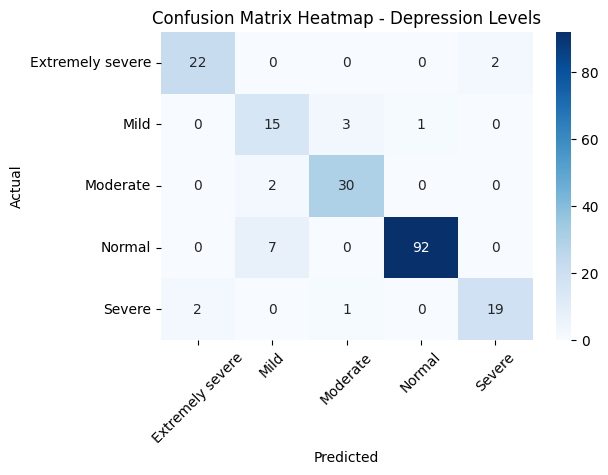

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get the labels from the lg classes to ensure correct order
labels = lg.classes_
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.xticks(rotation=45)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap - Depression Levels')
plt.show()

##**Interpretation**

Actual Normal but Predicted Mild: 7

Actual Mild but Predicted Moderate: 3

Actual Moderate but Predicted Mild: 2

Actual Severe but Predicted Extremely Severe: 2

Actual Extremely Severe but Predicted Severe: 2

---



###**Report:**
Examination of the confusion matrix indicates that misclassifications primarily occurred between adjacent severity categories rather than distant categories. This suggests the model captured the ordered structure of depression severity, although class boundaries remained partially overlapping.


###**Cross Val-Score**

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

# Because depression_level is imbalanced. Each fold keeps class proportions similar.
cv = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)

cv_results = cross_validate(lg, X_train_scaled, y_train, cv=cv, scoring=scoring)

print(f"Mean Accuracy: {cv_results['test_accuracy'].mean():.4f}  Standard Deviation: {cv_results['test_accuracy'].std():.4f}")
print(f"Mean Precision (Weighted): {cv_results['test_precision_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_precision_weighted'].std():.4f}")
print(f"Mean Recall (Weighted): {cv_results['test_recall_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_recall_weighted'].std():.4f}")
print(f"Mean F1-Score (Weighted): {cv_results['test_f1_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_f1_weighted'].std():.4f}")

Mean Accuracy: 0.9002  Standard Deviation: 0.0332
Mean Precision (Weighted): 0.9177  Standard Deviation: 0.0404
Mean Recall (Weighted): 0.9002  Standard Deviation: 0.0332
Mean F1-Score (Weighted): 0.9007  Standard Deviation: 0.0365


#**Implementing Pipeline**
* Data Leakage Fix

In [ ]:
X = mh_T1[features]
y = mh_T1['depression_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
pipe = Pipeline([
    ('transformer', transformer),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))])

###Cross-Validation with Pipeline:
If I repeatedly train on part of my training data, does performance stay stable on unseen portions?

In [ ]:
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']

cv = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)

cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)

print(f"Mean Accuracy: {cv_results['test_accuracy'].mean():.4f}  Standard Deviation: {cv_results['test_accuracy'].std():.4f}")
print(f"Mean Precision (Weighted): {cv_results['test_precision_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_precision_weighted'].std():.4f}")
print(f"Mean Recall (Weighted): {cv_results['test_recall_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_recall_weighted'].std():.4f}")
print(f"Mean F1-Score (Weighted): {cv_results['test_f1_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_f1_weighted'].std():.4f}")
print(f"Mean F1-Score (Macro): {cv_results['test_f1_macro'].mean():.4f}  Standard Deviation: {cv_results['test_f1_macro'].std():.4f}")

Mean Accuracy: 0.9066  Standard Deviation: 0.0503
Mean Precision (Weighted): 0.9258  Standard Deviation: 0.0401
Mean Recall (Weighted): 0.9066  Standard Deviation: 0.0503
Mean F1-Score (Weighted): 0.9091  Standard Deviation: 0.0473
Mean F1-Score (Macro): 0.8641  Standard Deviation: 0.0714


High mean → model learns useful patterns

Low std → model is stable

Large train–CV gap → possible overfitting

In [ ]:
print(cv_results['test_f1_weighted'].mean())

print(cv_results['test_f1_weighted'].std())

0.9090996300364204
0.04728325313775491


In [ ]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tnf1',
                                                  OrdinalEncoder(categories=[['Did '
                                                                              'not '
                                                                              'apply '
                                                                              'to '
                                                                              'me '
                                                                              'at '
                                                                              'all',
                                                                              'Applied '
                                                                              'to '
                                                                              'me '
                                                                              'to '
                                                                              'some '
                                                                              'degree '
                                                                              'of '
                                                                              'some '
                                                                              'of '
                                                                              'the '
                                                                              'time',
                                                                              'Applied '
                                                                              'to '
                                                                              'me '
                                                                              'to '
                                                                              'a '
                                                                              'considerable '
                                                                              'time '
                                                                              'or '
                                                                              'good '
                                                                              'part '
                                                                              'of '
                                                                              'time',
                                                                              'Applied '
                                                                              'to '
                                                                              'me '
                                                                              'very '
                                                                              'much '
                                                                              'or '
                                                                              'most '
                                                                              'of '
                                                                              'the '
                                                                              'time'],
                                                                             ['Di...
                                                   'felt_being_touchy',
                                                   'abnormal_heart_rate',
                                                   'felt_scared_without_reason',
                                                   'felt_life_is_meaningless']),
                                      

In [ ]:
pipe['model'].n_iter_

array([78], dtype=int32)

In [ ]:
y_pred = pipe.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nWeighted F1:")
print(f1_score(y_test, y_pred, average='weighted'))

print("\nF1 macro:")
print(f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.9081632653061225

Weighted F1:
0.9115488954567027

F1 macro:
0.8730972515856237

Classification Report:
                  precision    recall  f1-score   support

Extremely severe       0.92      0.92      0.92        24
            Mild       0.62      0.79      0.70        19
        Moderate       0.88      0.94      0.91        32
          Normal       0.99      0.93      0.96        99
          Severe       0.90      0.86      0.88        22

        accuracy                           0.91       196
       macro avg       0.86      0.89      0.87       196
    weighted avg       0.92      0.91      0.91       196


Confusion Matrix:
[[22  0  0  0  2]
 [ 0 15  3  1  0]
 [ 0  2 30  0  0]
 [ 0  7  0 92  0]
 [ 2  0  1  0 19]]


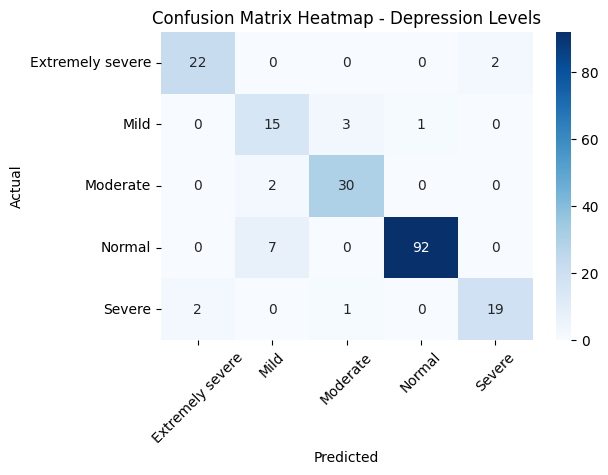

In [ ]:
labels = pipe.classes_
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.xticks(rotation=45)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap - Depression Levels')
plt.show()

##Feature Importance

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(pipe, X_test, y_test, scoring='f1_weighted', n_repeats=30, random_state=42)        # repeat shuffling for stability

importance_df = pd.DataFrame({'Feature':features,'Importance':result.importances_mean,
                              'Importance in %':result.importances_mean * 100,'Std':result.importances_std })

importance_df = (importance_df.sort_values(by='Importance',ascending=False))
importance_df

Loading ITables v2.8.1 from the internet... (need help?)


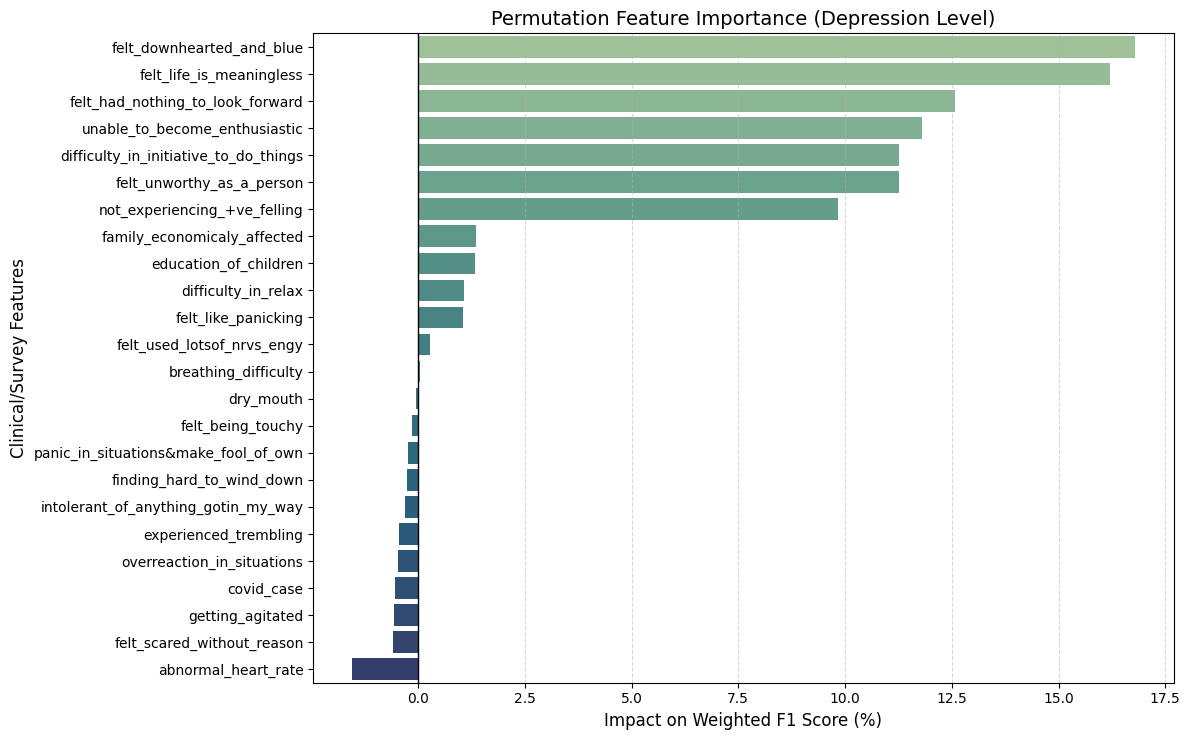

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Removing transformer prefixes
plot_df = importance_df.copy()
plot_df['Feature'] = plot_df['Feature'].str.replace('tnf1__', '').str.replace('tnf2__', '')
plot_df['Importance'] = plot_df['Importance'] * 100

plt.figure(figsize=(12, 7.5))
sns.barplot(x='Importance', y='Feature', data=plot_df, hue='Feature', palette='crest', legend=False)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.title('Permutation Feature Importance (Depression Level)', fontsize=14)
plt.xlabel('Impact on Weighted F1 Score (%)', fontsize=12)
plt.ylabel('Clinical/Survey Features', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# 'family_economicaly_affected', 'education_of_children', 'covid_case'
print(mh_T1['family_economicaly_affected'].unique())
print(mh_T1['education_of_children'].unique())
print(mh_T1['covid_case'].unique())

['Reduced income due to poor business' 'Pay cut' 'No / No Applicable'
 'Irregular pay' 'Lost job' 'Any other way']
['Somewhat affected' 'Unknown' 'Severely affected' 'Not affected']
['Covid deaths' 'No' 'Only Covid cases']


##Evaluating without `Covid-Case`

In [ ]:
features = ordinal_cols + ['family_economicaly_affected', 'education_of_children']
Xmod = mh_T1[features]
ymod = mh_T1['depression_level']

In [ ]:
Xmod = mh_T1[features]
ymod = mh_T1['depression_level']

Xmod_train, Xmod_test, ymod_train, ymod_test = train_test_split(Xmod, ymod, test_size=0.2, random_state=42, stratify=ymod)

In [ ]:
transformer_new = ColumnTransformer(transformers=[
    ('tnf1', OrdinalEncoder(categories=[['Did not apply to me at all',
                                         'Applied to me to some degree of some of the time',
                                         'Applied to me to a considerable time or good part of time',
                                         'Applied to me very much or most of the time']] * len(ordinal_cols)), ordinal_cols),
    ('tnf2', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), ['family_economicaly_affected', 'education_of_children'])
], remainder='passthrough')

In [ ]:
pipe_new = Pipeline([
    ('transformer', transformer_new),
    ('scaler', StandardScaler()),
    ('model_new', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))])

In [ ]:
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']

cv = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)

cv_results = cross_validate(pipe_new, Xmod_train, ymod_train, cv=cv, scoring=scoring)

print(f"Mean Accuracy: {cv_results['test_accuracy'].mean():.4f}  Standard Deviation: {cv_results['test_accuracy'].std():.4f}")
print(f"Mean Precision (Weighted): {cv_results['test_precision_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_precision_weighted'].std():.4f}")
print(f"Mean Recall (Weighted): {cv_results['test_recall_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_recall_weighted'].std():.4f}")
print(f"Mean F1-Score (Weighted): {cv_results['test_f1_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_f1_weighted'].std():.4f}")
print(f"Mean F1-Score (Macro): {cv_results['test_f1_macro'].mean():.4f}  Standard Deviation: {cv_results['test_f1_macro'].std():.4f}")

Mean Accuracy: 0.9079  Standard Deviation: 0.0547
Mean Precision (Weighted): 0.9282  Standard Deviation: 0.0408
Mean Recall (Weighted): 0.9079  Standard Deviation: 0.0547
Mean F1-Score (Weighted): 0.9104  Standard Deviation: 0.0520
Mean F1-Score (Macro): 0.8668  Standard Deviation: 0.0787


In [ ]:
print(cv_results['test_f1_weighted'].mean())

print(cv_results['test_f1_weighted'].std())

0.9103921242135298
0.0520349894234811


In [ ]:
pipe_new.fit(Xmod_train, ymod_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tnf1',
                                                  OrdinalEncoder(categories=[['Did '
                                                                              'not '
                                                                              'apply '
                                                                              'to '
                                                                              'me '
                                                                              'at '
                                                                              'all',
                                                                              'Applied '
                                                                              'to '
                                                                              'me '
                                                                              'to '
                                                                              'some '
                                                                              'degree '
                                                                              'of '
                                                                              'some '
                                                                              'of '
                                                                              'the '
                                                                              'time',
                                                                              'Applied '
                                                                              'to '
                                                                              'me '
                                                                              'to '
                                                                              'a '
                                                                              'considerable '
                                                                              'time '
                                                                              'or '
                                                                              'good '
                                                                              'part '
                                                                              'of '
                                                                              'time',
                                                                              'Applied '
                                                                              'to '
                                                                              'me '
                                                                              'very '
                                                                              'much '
                                                                              'or '
                                                                              'most '
                                                                              'of '
                                                                              'the '
                                                                              'time'],
                                                                             ['Di...
                                                   'felt_being_touchy',
                                                   'abnormal_heart_rate',
                                                   'felt_scared_without_reason',
                                                   'felt_life_is_meaningless']),
                                      

In [ ]:
pipe_new['model_new'].n_iter_

array([84], dtype=int32)

In [ ]:
ymod_pred = pipe_new.predict(Xmod_test)

print("Accuracy:")
print(accuracy_score(ymod_test, ymod_pred))

print("\nWeighted F1:")
print(f1_score(ymod_test, ymod_pred, average='weighted'))

print("\nF1 macro:")
print(f1_score(ymod_test, ymod_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(ymod_test, ymod_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(ymod_test, ymod_pred))

Accuracy:
0.9183673469387755

Weighted F1:
0.920740813473181

F1 macro:
0.8871992164427397

Classification Report:
                  precision    recall  f1-score   support

Extremely severe       0.92      1.00      0.96        24
            Mild       0.65      0.79      0.71        19
        Moderate       0.90      0.88      0.89        32
          Normal       0.99      0.94      0.96        99
          Severe       0.91      0.91      0.91        22

        accuracy                           0.92       196
       macro avg       0.88      0.90      0.89       196
    weighted avg       0.93      0.92      0.92       196


Confusion Matrix:
[[24  0  0  0  0]
 [ 0 15  3  1  0]
 [ 0  2 28  0  2]
 [ 0  6  0 93  0]
 [ 2  0  0  0 20]]


##Report:
 Overall performance improvement.

 * Previous Mean F1-Score (Weighted): 0.9091
 * Current Mean F1-Score (Weighted):  0.9104  



###**Confusion Matrix comparison**




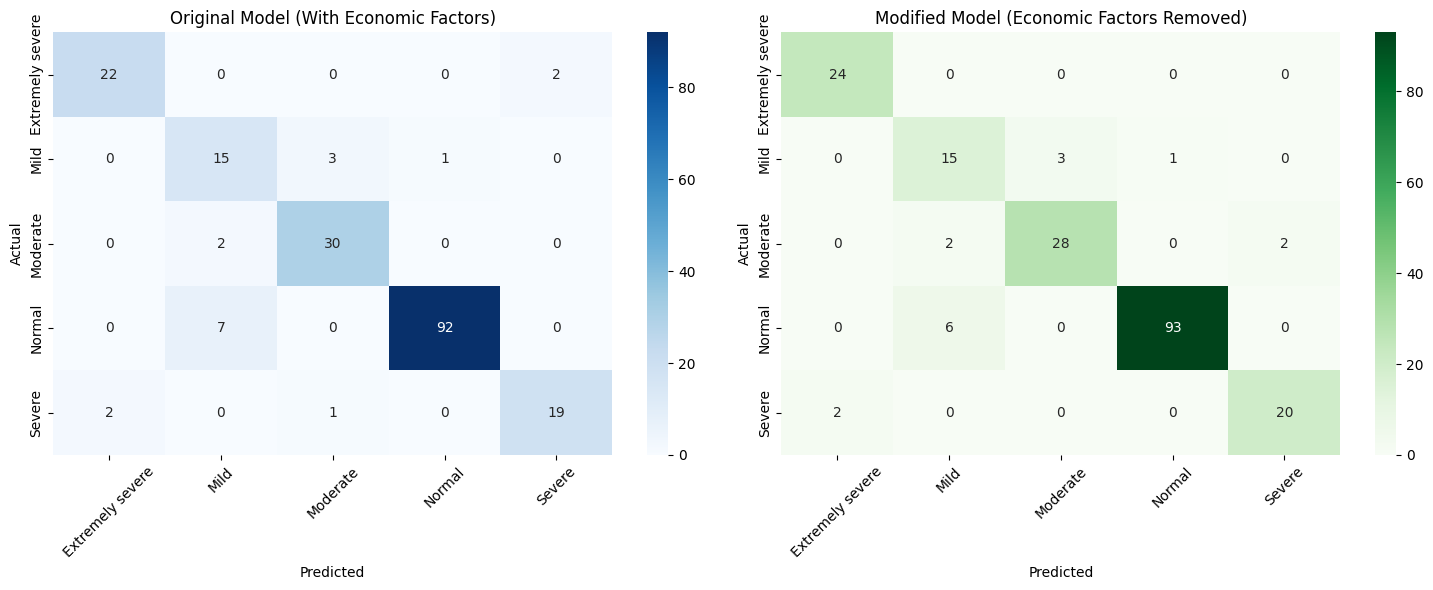

In [ ]:
labels = pipe.classes_
cm_orig = confusion_matrix(y_test, y_pred, labels=labels)
cm_mod = confusion_matrix(ymod_test, ymod_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original Model Heatmap
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Original Model (With Economic Factors)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

# Modified Model Heatmap
sns.heatmap(cm_mod, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Modified Model (Economic Factors Removed)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
ymod_test.value_counts()

Loading ITables v2.8.1 from the internet... (need help?)


## Depression Measures (7 items)

These questions assess symptoms associated with **depressive emotional states**, including **sadness, hopelessness, reduced pleasure, reduced initiative, and negative self-evaluation**.

| Column Name | Questionnaire Item |
|---|---|
| `not_experiencing_+ve_felling` | I couldn’t seem to experience any positive feeling at all. |
| `difficulty_in_initiative_to_do_things` | I found it difficult to work up the initiative to do things. |
| `felt_had_nothing_to_look_forward` | I felt that I had nothing to look forward to. |
| `felt_downhearted_and_blue` | I felt down-hearted and blue. |
| `unable_to_become_enthusiastic` | I was unable to become enthusiastic about anything. |
| `felt_unworthy_as_a_person` | I felt I wasn’t worth much as a person. |
| `felt_life_is_meaningless` | I felt that life was meaningless. |


##**Report:**
According to the permutation importance analysis, these variables contributed most strongly to the predictive performance of the model in classifying depression severity levels. Notably, these variables correspond to the seven DASS-21 items that are designed to measure depressive symptoms and collectively form the depression subscale of the questionnaire.

Therefore, the findings are consistent with the theoretical structure of the DASS-21 framework and provide support that these depressive symptom indicators played a substantial role in distinguishing between different levels of depression severity within the dataset. However, these results should be interpreted as indicators of `predictive contribution` within the model rather than evidence of causal influence.


In [ ]:
import joblib

# Depression

y = mh_T1['depression_level']

joblib.dump(
    pipe_new,
    'depression_model.joblib'
)

['depression_model.joblib']

### **`Decision Boundaries of Logistic Regressor`**

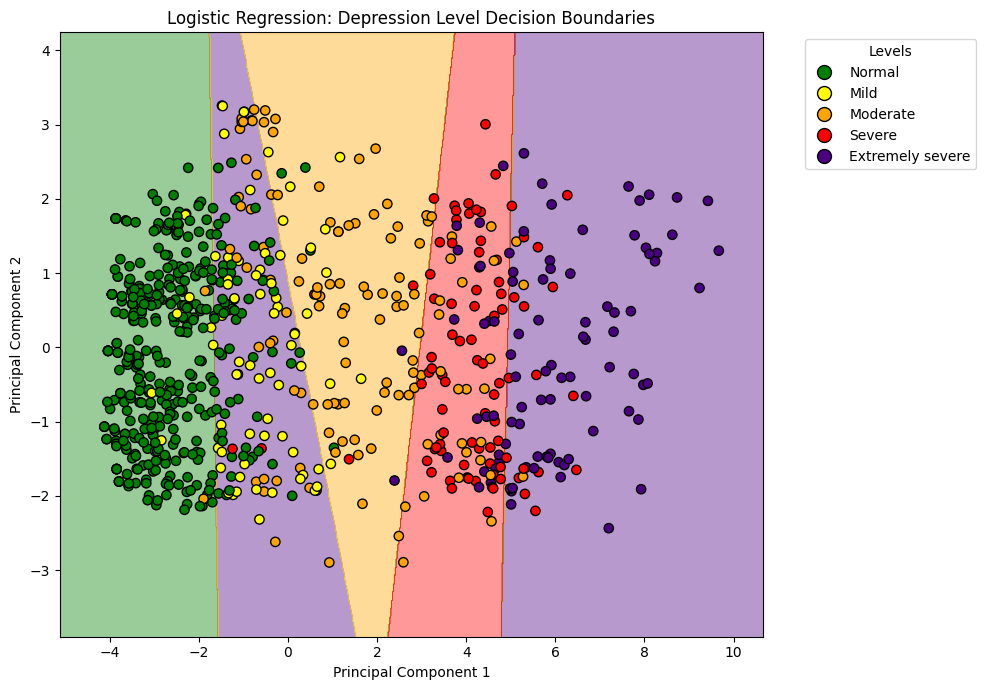

In [ ]:
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

logic_order = ['Normal', 'Mild', 'Moderate', 'Severe', 'Extremely severe']
logic_colors = ['#008000', '#FFFF00', '#FFA500', '#FF0000', '#4B0082']

# Setup LabelEncoder based on the training data
le = LabelEncoder()
le.fit(ymod_train)

class_to_color = {
    'Normal': '#008000',
    'Mild': '#FFFF00',
    'Moderate': '#FFA500',
    'Severe': '#FF0000',
    'Extremely severe': '#4B0082'
}
alphasorted_colors = [class_to_color[cls] for cls in le.classes_]
my_cmap = ListedColormap(alphasorted_colors)

# Fix: Create Xmod_train_scaled by using the pipeline's preprocessing steps
# We fit the preprocessing part of the pipeline to the data
preprocessor = Pipeline(steps=pipe_new.steps[:-1])
Xmod_train_scaled = preprocessor.fit_transform(Xmod_train, ymod_train)

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
Xmod_pca = pca.fit_transform(Xmod_train_scaled)

# Train visualizer
lg_viz = LogisticRegression(class_weight='balanced')
lg_viz.fit(Xmod_pca, ymod_train)

# Create mesh grid for boundaries
h = .02
x_min, x_max = Xmod_pca[:, 0].min() - 1, Xmod_pca[:, 0].max() + 1
y_min, y_max = Xmod_pca[:, 1].min() - 1, Xmod_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = lg_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z_encoded = le.transform(Z).reshape(xx.shape)
y_encoded = le.transform(ymod_train)

# Plotting
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z_encoded, cmap=my_cmap, alpha=0.4)
scatter = plt.scatter(Xmod_pca[:, 0], Xmod_pca[:, 1], c=y_encoded, cmap=my_cmap, edgecolors='k', s=45)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Logistic Regression: Depression Level Decision Boundaries')

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=label,
                          markerfacecolor=class_to_color[label], markersize=10, markeredgecolor='k')
                   for label in logic_order]

plt.legend(handles=legend_elements, title="Levels", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# **Predicting Anxiety Levels**
We will now use the same feature set $X$ (without economic factors) to predict `Anxiety level` and independently using Logistic Regression. As stress & anxiety levels are also being predicted by the same X feature so we are going to remove the 'Economic Factor'.

In [ ]:
Xa = mh_T1[features]
ya = mh_T1['anxiety_level']

Xa_train, Xa_test, ya_train, ya_test = train_test_split(Xa, ya, test_size=0.2, random_state=42, stratify=ya)

In [ ]:
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']

cva = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)

cv_results = cross_validate(pipe_new, Xa_train, ya_train, cv=cva, scoring=scoring)      #using the same pipeline as X features did not changed

print(f"Mean Accuracy: {cv_results['test_accuracy'].mean():.4f}  Standard Deviation: {cv_results['test_accuracy'].std():.4f}")
print(f"Mean Precision (Weighted): {cv_results['test_precision_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_precision_weighted'].std():.4f}")
print(f"Mean Recall (Weighted): {cv_results['test_recall_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_recall_weighted'].std():.4f}")
print(f"Mean F1-Score (Weighted): {cv_results['test_f1_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_f1_weighted'].std():.4f}")
print(f"Mean F1-Score (Macro): {cv_results['test_f1_macro'].mean():.4f}  Standard Deviation: {cv_results['test_f1_macro'].std():.4f}")

Mean Accuracy: 0.8991  Standard Deviation: 0.0365
Mean Precision (Weighted): 0.9297  Standard Deviation: 0.0306
Mean Recall (Weighted): 0.8991  Standard Deviation: 0.0365
Mean F1-Score (Weighted): 0.9068  Standard Deviation: 0.0334
Mean F1-Score (Macro): 0.7983  Standard Deviation: 0.0818


In [ ]:
pipe_new.fit(Xa_train, ya_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tnf1',
                                                  OrdinalEncoder(categories=[['Did '
                                                                              'not '
                                                                              'apply '
                                                                              'to '
                                                                              'me '
                                                                              'at '
                                                                              'all',
                                                                              'Applied '
                                                                              'to '
                                                                              'me '
                                                                              'to '
                                                                              'some '
                                                                              'degree '
                                                                              'of '
                                                                              'some '
                                                                              'of '
                                                                              'the '
                                                                              'time',
                                                                              'Applied '
                                                                              'to '
                                                                              'me '
                                                                              'to '
                                                                              'a '
                                                                              'considerable '
                                                                              'time '
                                                                              'or '
                                                                              'good '
                                                                              'part '
                                                                              'of '
                                                                              'time',
                                                                              'Applied '
                                                                              'to '
                                                                              'me '
                                                                              'very '
                                                                              'much '
                                                                              'or '
                                                                              'most '
                                                                              'of '
                                                                              'the '
                                                                              'time'],
                                                                             ['Di...
                                                   'felt_being_touchy',
                                                   'abnormal_heart_rate',
                                                   'felt_scared_without_reason',
                                                   'felt_life_is_meaningless']),
                                      

In [ ]:
ya_pred = pipe_new.predict(Xa_test)

print("Accuracy:")
print(accuracy_score(ya_test, ya_pred))

print("\nWeighted F1:")
print(f1_score(ya_test, ya_pred, average='weighted'))

print("\nF1 macro:")
print(f1_score(ya_test, ya_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(ya_test, ya_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(ya_test, ya_pred))

Accuracy:
0.8928571428571429

Weighted F1:
0.9019924028845068

F1 macro:
0.7764633654221172

Classification Report:
                  precision    recall  f1-score   support

Extremely severe       1.00      0.90      0.95        50
            Mild       0.62      0.77      0.69        13
        Moderate       0.71      0.75      0.73        20
          Normal       1.00      0.95      0.98       103
          Severe       0.44      0.70      0.54        10

        accuracy                           0.89       196
       macro avg       0.76      0.81      0.78       196
    weighted avg       0.92      0.89      0.90       196


Confusion Matrix:
[[45  0  0  0  5]
 [ 0 10  3  0  0]
 [ 0  1 15  0  4]
 [ 0  5  0 98  0]
 [ 0  0  3  0  7]]


In [ ]:
# Depression
y = mh_T1['anxiety_level']

joblib.dump(
    pipe_new,
    'anxiety_model.joblib'
)

['anxiety_model.joblib']

###Confusion Matrix

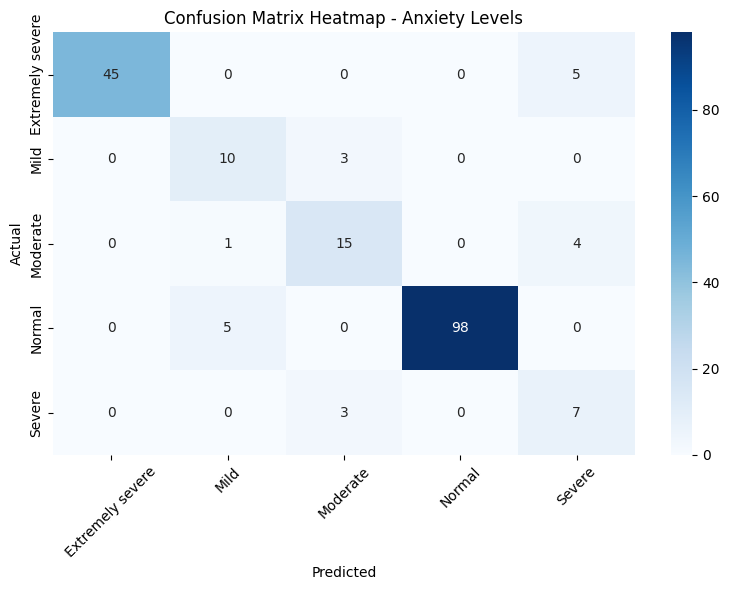

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get the labels from the pipeline classes to ensure correct order
labels = pipe_new.classes_
cma = confusion_matrix(ya_test, ya_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cma, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.xticks(rotation=45)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap - Anxiety Levels')
plt.tight_layout()
plt.show()

###Report:
The confusion matrix shows strong overall performance, with most predictions concentrated along the diagonal, indicating accurate classification across anxiety severity levels. Misclassifications occur primarily between adjacent severity classes (e.g., Mild → Moderate, Moderate → Severe, Severe → Extremely Severe), suggesting the model captures the underlying progression of anxiety rather than making arbitrary errors. Performance is strongest for Normal and Extremely Severe anxiety levels, while intermediate classes show comparatively lower separability. This pattern indicates clinically reasonable classification behavior despite class imbalance and the use of standard multiclass logistic regression.

###Feature Importance:

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(pipe_new, Xa_test, ya_test, scoring='f1_weighted', n_repeats=30, random_state=42)        # repeat shuffling for stability

importance_df = pd.DataFrame({'Feature':features,'Importance':result.importances_mean,
                              'Importance in %':result.importances_mean * 100,'Std':result.importances_std })

importance_df = (importance_df.sort_values(by='Importance',ascending=False))
importance_df

Loading ITables v2.8.1 from the internet... (need help?)


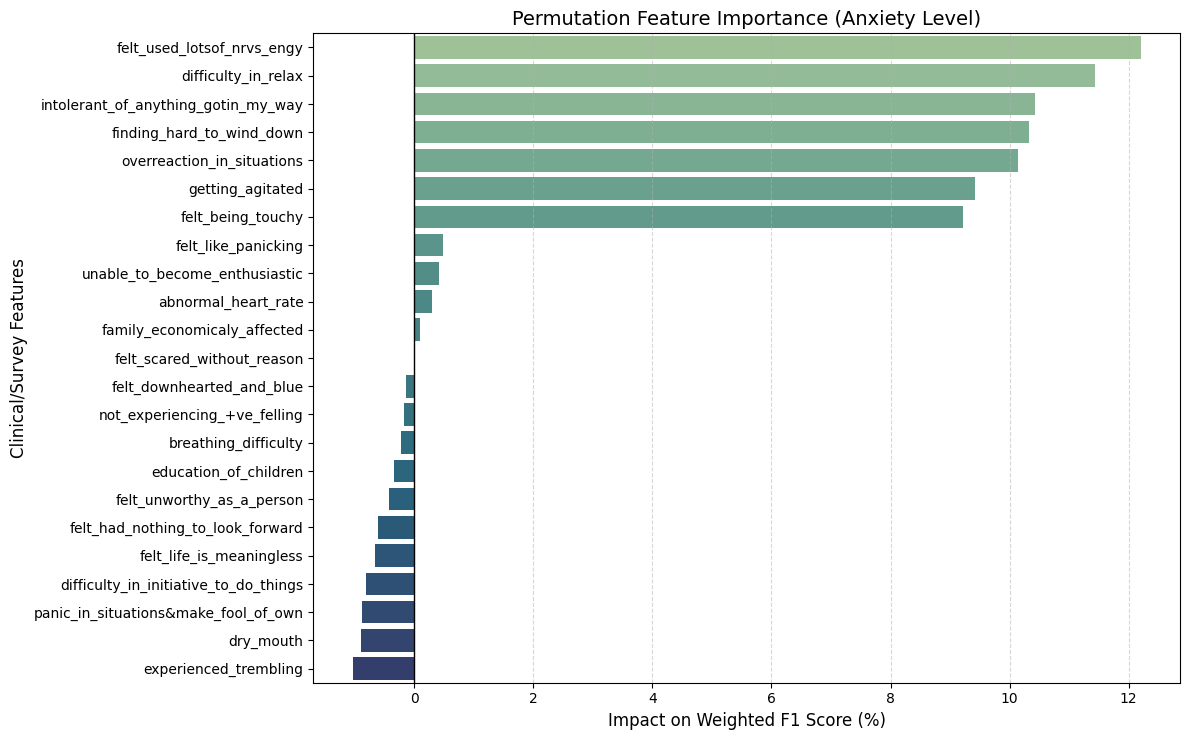

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Removing transformer prefixes
plot_df = importance_df.copy()
plot_df['Feature'] = plot_df['Feature'].str.replace('tnf1__', '').str.replace('tnf2__', '')
plot_df['Importance'] = plot_df['Importance'] * 100

plt.figure(figsize=(12, 7.5))
sns.barplot(x='Importance', y='Feature', data=plot_df, hue='Feature', palette='crest', legend=False)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.title('Permutation Feature Importance (Anxiety Level)', fontsize=14)
plt.xlabel('Impact on Weighted F1 Score (%)', fontsize=12)
plt.ylabel('Clinical/Survey Features', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
ya_test.value_counts()

Loading ITables v2.8.1 from the internet... (need help?)


## Anxiety Measures (7 items)

These questions assess **anxiety-related experiences**, including **fear responses, autonomic activation, panic sensations, and bodily symptoms associated with anxious arousal**.

| Column Name | Questionnaire Item |
|---|---|
| `dry_mouth` | I was aware of dryness of my mouth. |
| `breathing_difficulty` | I experienced breathing difficulty. |
| `experienced_trembling` | I experienced trembling. |
| `panic_in_situations&make_fool_of_own` | I was worried about situations in which I might panic and make a fool of myself. |
| `felt_like_panicking` | I felt I was close to panic. |
| `abnormal_heart_rate` | I was aware of the action of my heart in the absence of physical exertion. |
| `felt_scared_without_reason` | I felt scared without any good reason. |

##**Report:**
According to the permutation importance analysis, these variables contributed most strongly to the predictive performance of the model in classifying anxiety severity levels. Notably, these variables correspond to the seven DASS-21 items that are designed to measure anxiety symptoms and collectively form the anxiety subscale of the questionnaire.

Therefore, the findings are consistent with the theoretical structure of the DASS-21 framework and provide support that these anxiety symptom indicators played a substantial role in distinguishing between different levels of anxiety severity within the dataset. However, these results should be interpreted as indicators of `predictive contribution` within the model rather than evidence of causal influence.


## **Predicting Stress Levels**
We will now use the same feature set $X$ to predict `Stress level` and independently using Logistic Regression.

In [ ]:
Xs = mh_T1[features]
ys = mh_T1['stress_level']

Xs_train, Xs_test, ys_train, ys_test = train_test_split(Xs, ys, test_size=0.2, random_state=42, stratify=ys)

In [ ]:
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']

cvs = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)

cv_results = cross_validate(pipe_new, Xs_train, ys_train, cv=cvs, scoring=scoring)      #using the same pipeline as X features did not changed

print(f"Mean Accuracy: {cv_results['test_accuracy'].mean():.4f}  Standard Deviation: {cv_results['test_accuracy'].std():.4f}")
print(f"Mean Precision (Weighted): {cv_results['test_precision_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_precision_weighted'].std():.4f}")
print(f"Mean Recall (Weighted): {cv_results['test_recall_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_recall_weighted'].std():.4f}")
print(f"Mean F1-Score (Weighted): {cv_results['test_f1_weighted'].mean():.4f}  Standard Deviation: {cv_results['test_f1_weighted'].std():.4f}")
print(f"Mean F1-Score (Macro): {cv_results['test_f1_macro'].mean():.4f}  Standard Deviation: {cv_results['test_f1_macro'].std():.4f}")

Mean Accuracy: 0.9169  Standard Deviation: 0.0229
Mean Precision (Weighted): 0.9339  Standard Deviation: 0.0141
Mean Recall (Weighted): 0.9169  Standard Deviation: 0.0229
Mean F1-Score (Weighted): 0.9202  Standard Deviation: 0.0195
Mean F1-Score (Macro): 0.8436  Standard Deviation: 0.0445


In [ ]:
pipe_new.fit(Xs_train, ys_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tnf1',
                                                  OrdinalEncoder(categories=[['Did '
                                                                              'not '
                                                                              'apply '
                                                                              'to '
                                                                              'me '
                                                                              'at '
                                                                              'all',
                                                                              'Applied '
                                                                              'to '
                                                                              'me '
                                                                              'to '
                                                                              'some '
                                                                              'degree '
                                                                              'of '
                                                                              'some '
                                                                              'of '
                                                                              'the '
                                                                              'time',
                                                                              'Applied '
                                                                              'to '
                                                                              'me '
                                                                              'to '
                                                                              'a '
                                                                              'considerable '
                                                                              'time '
                                                                              'or '
                                                                              'good '
                                                                              'part '
                                                                              'of '
                                                                              'time',
                                                                              'Applied '
                                                                              'to '
                                                                              'me '
                                                                              'very '
                                                                              'much '
                                                                              'or '
                                                                              'most '
                                                                              'of '
                                                                              'the '
                                                                              'time'],
                                                                             ['Di...
                                                   'felt_being_touchy',
                                                   'abnormal_heart_rate',
                                                   'felt_scared_without_reason',
                                                   'felt_life_is_meaningless']),
                                      

In [ ]:
ys_pred = pipe_new.predict(Xs_test)

print("Accuracy:")
print(accuracy_score(ys_test, ys_pred))

print("\nWeighted F1:")
print(f1_score(ys_test, ys_pred, average='weighted'))

print("\nF1 macro:")
print(f1_score(ys_test, ys_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(ys_test, ys_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(ys_test, ys_pred))

Accuracy:
0.9438775510204082

Weighted F1:
0.9440708641546142

F1 macro:
0.8900330474775556

Classification Report:
                  precision    recall  f1-score   support

Extremely severe       0.78      0.88      0.82         8
            Mild       0.80      1.00      0.89        16
        Moderate       0.85      1.00      0.92        22
          Normal       1.00      0.97      0.98       126
          Severe       0.95      0.75      0.84        24

        accuracy                           0.94       196
       macro avg       0.87      0.92      0.89       196
    weighted avg       0.95      0.94      0.94       196


Confusion Matrix:
[[  7   0   0   0   1]
 [  0  16   0   0   0]
 [  0   0  22   0   0]
 [  0   4   0 122   0]
 [  2   0   4   0  18]]


In [ ]:
y = mh_T1['stress_level']

joblib.dump(
    pipe_new,
    'stress_model.joblib'
)

['stress_model.joblib']

In [ ]:
ys_test.value_counts()

Loading ITables v2.8.1 from the internet... (need help?)


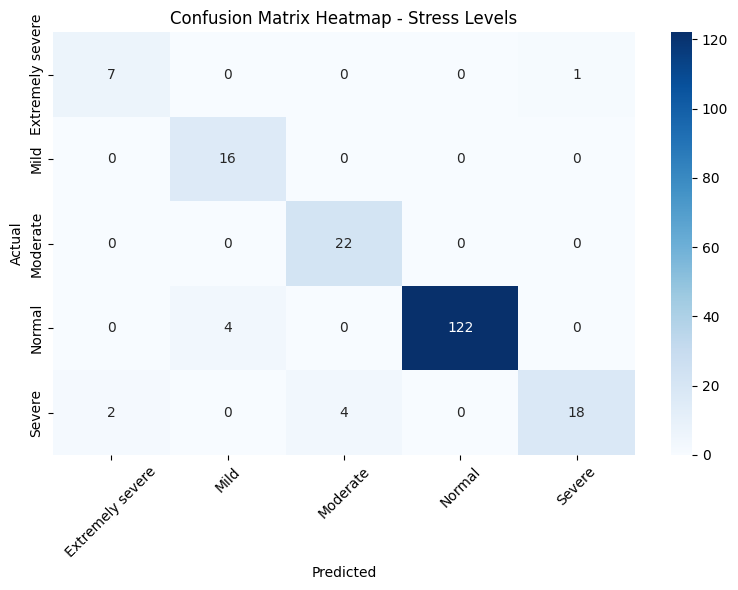

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get the labels from the pipeline classes to ensure correct order
labels = pipe_new.classes_
cms = confusion_matrix(ys_test, ys_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cms, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.xticks(rotation=45)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap - Stress Levels')
plt.tight_layout()
plt.show()

###Report
The confusion matrix indicates strong classification performance, with most predictions concentrated along the diagonal and high accuracy across all anxiety severity categories. Misclassifications occur predominantly between adjacent severity classes (e.g., Severe → Moderate and Extremely Severe → Severe), suggesting the model preserves the ordinal structure of anxiety severity rather than making large prediction jumps. The model performs particularly well for Normal, Mild, and Moderate classes, while maintaining reasonable separation for higher severity levels despite some overlap. Overall, the error pattern reflects stable and clinically plausible classification behavior.

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(pipe_new, Xs_test, ys_test, scoring='f1_weighted', n_repeats=30, random_state=42)        # repeat shuffling for stability

importance_df = pd.DataFrame({'Feature':features,'Importance':result.importances_mean,
                              'Importance in %':result.importances_mean * 100,'Std':result.importances_std })

importance_df = (importance_df.sort_values(by='Importance',ascending=False))
importance_df

Loading ITables v2.8.1 from the internet... (need help?)


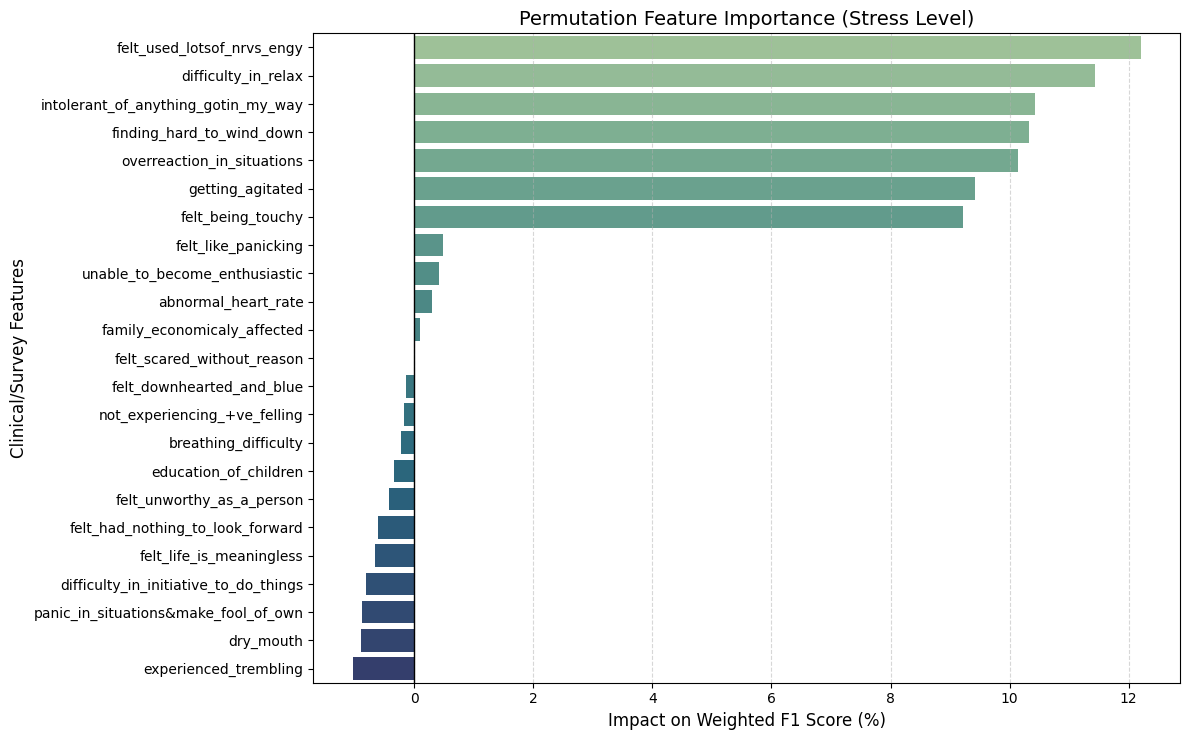

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Removing transformer prefixes
plot_df = importance_df.copy()
plot_df['Feature'] = plot_df['Feature'].str.replace('tnf1__', '').str.replace('tnf2__', '')
plot_df['Importance'] = plot_df['Importance'] * 100

plt.figure(figsize=(12, 7.5))
sns.barplot(x='Importance', y='Feature', data=plot_df, hue='Feature', palette='crest', legend=False)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.title('Permutation Feature Importance (Stress Level)', fontsize=14)
plt.xlabel('Impact on Weighted F1 Score (%)', fontsize=12)
plt.ylabel('Clinical/Survey Features', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

###**Feature Importance:**

## Stress Measures (7 items)

These questions assess **psychological stress and tension**, including **agitation, nervous energy, irritability, and difficulty relaxing**.

| Column Name | Questionnaire Item |
|---|---|
| `finding_hard_to_wind_down` | I found it hard to wind down. |
| `overreaction_in_situations` | I tended to over-react to situations. |
| `felt_used_lotsof_nrvs_engy` | I felt that I was using a lot of nervous energy. |
| `getting_agitated` | I found myself getting agitated. |
| `difficulty_in_relax` | I found it difficult to relax. |
| `intolerant_of_anything_gotin_my_way` | I was intolerant of anything that kept me from getting on with what I was doing. |
| `felt_being_touchy` | I felt that I was rather touchy. |

##**Report:**
According to the permutation importance analysis, these variables contributed most strongly to the predictive performance of the model in classifying stress severity levels. Notably, these variables correspond to the seven DASS-21 items that are designed to measure stress symptoms and collectively form the stress subscale of the questionnaire.

Therefore, the findings are consistent with the theoretical structure of the DASS-21 framework and provide support that these stress symptom indicators played a substantial role in distinguishing between different levels of stress severity within the dataset. However, these results should be interpreted as indicators of `predictive contribution` within the model rather than evidence of causal influence.


In [ ]:



# Anxiety

y = mh_T1['anxiety_level']

pipe_anx.fit(Xa_train, ya_train)

joblib.dump(
    pipe_anx,
    'anxiety_model.joblib'
)


# Stress

y = mh_T1['stress_level']

pipe_stress.fit(Xs_train, ys_train)

joblib.dump(
    pipe_stress,
    'stress_model.joblib'
)

NameError: name 'pipe_dep' is not defined